# The three-level controller

A three-level controller is a discontinuous controller with three output states. Depending on whether the actual value is below the first target value, between the first and second target value, or above the second target value, the first, second or third state is adopted. Three-point controllers are used when the manipulated variable is not continuously variable.

<img src = "./model.svg" width=150px>

## Model equations

The change in the manipulated variable caused by the two-level controller is calculated as follows:


$$ e < - \frac{hyst}{2} \Rightarrow y = y_{min}$$
$$ e >  \frac{hyst}{2} \Rightarrow y = y_{max}$$
$$ e >  \frac{hyst}{2} \wedge e < - \frac{hyst}{2} \Rightarrow y = \frac{y_{max}-y_{min}}{2}$$

with:

$hyst$ = Hysteresis

$e$ = Error, Difference between set point and process value

$y$ = Change of the manipulated value

## Parameters

The equations will be integrated with the follwing parameters.

| Parameter | Symbol | Value | Unit | 
| :------- | :----: | :---: | :---- |
| Manipulated value limits | $y_{min}$, $y_{max}$ | 40.0, 20.0 | mA |
| Hysteresis | $hyst$ | 0.05 | mA |

## Application using the example of an exothermic reaction in a stirred tank.

For further information please have look into [cstr.ipynb](./cstr.ipynb) and [pid-controller.ipynb](./pid-controller.ipynb).

### Implementation of the  test case

In [1]:
import numpy as np

Ea  = 72750.0  # Activation energy [J/mol]
R   = 8.314    # Gas constant [J/mol/K]
k0  = 7.2e10   # Arrhenius rate constant [1/min]
V   = 100.0    # Volume [l]
rho = 1000.0   # Density [g/l]
Cp  = 0.239    # Heat capacity [J/g/K]
dHr = -5.0e4   # Enthalpy of reaction [J/mol]
UA  = 5.0e4    # Heat transfer [J/min/K]
q   = 100.0    # Flowrate [l/min]
cAf = 1.0      # Inlet feed concentration [mol/l]
Trf  = 300.0   # Inlet feed temperature [K]
cA0 = 0.5      # Initial concentration [mol/l]
Tr0  = 350.0;  # Initial temperature [K]
Tcf = 300.0    # Coolant feed temperature [K]
qc  = 50.0     # Nominal coolant flowrate [l/min]
Vc  = 20.0     # Cooling jacket volume [l]

def cstr(z, t, theta):
    # State variables
    cA, Tr, Tc = z
    # Parameters
    qc = theta
    
    # Arrhenius rate expression
    k = k0*np.exp(-Ea/R/Tr)
    
    # Differential equations
    dcA = (q/V)*(cAf-cA) - k*cA
    dTr = (q/V)*(Trf-Tr) + (-dHr/rho/Cp)*k*cA + (UA/V/rho/Cp)*(Tc-Tr)
    dTc = (qc/Vc)*(Tcf-Tc) + (UA/Vc/rho/Cp)*(Tr-Tc)
    
    return [dcA, dTr, dTc]

### Implementation of the result visualization

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_result(t_frame, c_A, T_r, T_c, q_c, T_sp):
    # Create matplotlib figure and axis
    fig = plt.figure(figsize=(9, 5))  

    # Add grid spec
    gs = fig.add_gridspec(5, 1)

    # Draw 10 markers on every line plot
    points = int(len(t_frame)/10)

    # Create a subplot in the top of the figure
    ax_top = plt.subplot(gs[0:2, 0])

    # Plot cool medium flow rate
    line0 = ax_top.plot(t_frame, q_c, "C3-D", label="$q_c$", markevery=points)

    # Set axis label
    ax_top.set_ylabel("Cooling flow rate [l/min]")

    # Add legend to the top subplot
    ax_top.legend(loc=1)

    # Tune axis (show grid and remove x-labels)
    ax_top.grid()
    for xlabel_i in ax_top.axes.get_xticklabels():
        xlabel_i.set_visible(False)
        xlabel_i.set_fontsize(0.0)

    # Create a subplot at the bottom of the figure
    # share x axis with the top subplot
    ax_bottom = plt.subplot(gs[2:5, 0], sharex = ax_top)

    # Plot recator temperature set point
    line1 = ax_bottom.plot(t_frame, T_sp,'C3', label="$T_{r, set}$")

    # Plot inner reactor temperature
    line2 = ax_bottom.plot(t_frame , T_r, "C0-D", label="$T_r$", markevery=points)

    # Plot reactor cooling jacket temperature
    line3 = ax_bottom.plot(t_frame , T_c, "C1-o", label="$T_c$", markevery=points)

    # Set axis labels
    ax_bottom.set_ylabel("Temperature [K]")
    ax_bottom.set_xlabel("Time [min]")

    # Tune axis 
    ax_bottom.grid()
    ax_bottom.xaxis.set_major_locator(ticker.AutoLocator())
    ax_bottom.xaxis.set_minor_locator(ticker.AutoMinorLocator())   

    # Create a second y-axes in the bottom subplot that shares the x-axis 
    ax_bottom_twin = ax_bottom.twinx()  

    # Plot concentration of component A
    line4 = ax_bottom_twin.plot(t_frame, c_A, "C2-s", label="$c_A$", markevery=points)

    # Set axis label
    ax_bottom_twin.set_ylabel("Concentration [mol/l]")

    # Create legend
    lines = line1 + line2 + line3 + line4
    labels = [line.get_label() for line in lines]
    ax_bottom_twin.legend(lines, labels, loc=1)        

    #  Show plot
    plt.tight_layout()
    plt.show()


### Computation and result of the uncontrolled test case

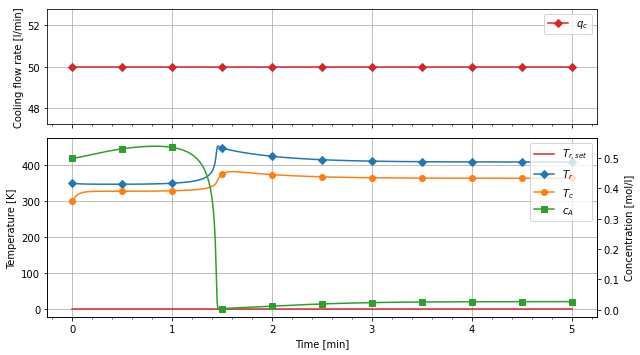

In [3]:
from scipy.integrate import odeint
import numpy as np

# ODE solver parameter
abserr = 1.0e-8
relerr = 1.0e-6

# Setup integration time
t_start = 0.0
t_end = 5.0
numpoints = 1001
t = np.linspace(t_start, t_end, numpoints)

y_sol = odeint(
    cstr, [cA0, Tr0, Tcf], t, args=(150.0,), 
    atol=abserr, rtol=relerr)
cA = y_sol[:,0]
Tr = y_sol[:,1]
Tc = y_sol[:,2]

plot_result(t, cA, Tr, Tc, np.full(numpoints, qc), np.zeros(numpoints))

## Implementation of the controller model


In [7]:
from simunetcore import Model
import numpy as np

# Model implementation for the 2-level controller
class TwoLevelController(Model):
    def __init__(self, name=""):
        Model.__init__(self, name)
        # Model parameters
        self.params = {
            "y_range" : {"value": [4.0, 20.0], "description": "Range of controller output", "unit": ""},
            "hysteresis" : {"value": 0.1, "description": "Switch hysteresis", "unit": ""},
            "delta_t" : {"value": 0.0, "description": "Time intervall", "unit": "s"}
        }
        # Model variables
        self.vars = {
            "p_v" : {"description": "Process value", "unit": ""}, 
            "m_v" : {"description": "Manipulated value", "unit": ""},
            "s_p" : {"description": "Set Point", "unit": ""}
        }
        # Model inputs
        self.u = {
            "u_1" : {"type": "signal", "description": "Instrument input", "vars": ["p_v"]},
            "u_2" : {"type": "signal", "description": "Set Point input", "vars": ["s_p"]}
        }
        # Model outputs
        self.y = {
            "y_1" : {"type": "control", "description": "Controller output", "vars": ["m_v"]}
        }
        self.__t_last = 0
        
    def compute(self, *args, **kwargs):
         # Parameters
        y_min, y_max = self.get_param("y_range")
        hysteresis = self.get_param("hysteresis")
        delta_t = self.get_param("delta_t")
        t_frame = self.get_t()
        
        # Create python list to log results
        result = []

        # Get inital manipulated value
        m_v = self.get_var("m_v")[-1]

        for i in range(len(t_frame)):
            # Append current manipulated to the result
            result.append(m_v)

            # Get time step
            t = t_frame[i]
            
            # Evaluate only after time intervall (delta_t)
            if t >= self.__t_last + delta_t or delta_t == 0:
                # Get set point and process value for the time step
                s_p = self.get_var("s_p", t) 
                p_v = self.get_var("p_v", t)

                # Error calculations
                err = s_p - p_v

                # Three level control calculations
                if err < -hysteresis / 2.0:
                    m_v = y_min
                elif err > hysteresis / 2.0:
                    m_v = y_max
                else:
                    m_v = (y_min + y_max) / 2.0
                    
                # Increment __t_last    
                self.__t_last += delta_t
                
        # Return result array
        self.set_var("m_v", result)        

## Computation of the controlled test case

In [8]:
# Create model
M_6 = TwoLevelController("M_6")

# Set parameters
M_6.set_param("y_range", [350.0, 0.0]) 
M_6.set_param("hysteresis", 2.0) 

# Setpoint
Tsp=385.0
M_6.set_var("s_p", Tsp)

# Do simulation at fixed time steps dt from t_start
t_start = 0.0
t_end = 8.0
dt = 0.005

# Create python list to log results
result = []

# Set initial conditions and initial cooling flow
cA, Tr, Tc = cA0, Tr0, Tcf
qc = 150.0

for t in np.linspace(t_start, t_end, int((t_end-t_start)/dt)+1):
    # Switch set pooint at t=4 min
    if t == 4.0:
        Tsp= 400.0
        
    # log data and update state
    result.append([t, cA, Tr, Tc, qc, Tsp])
            
    # Start at t, find state at t + dt
    cA, Tr, Tc = odeint(
        cstr, [cA, Tr, Tc], [t, t+dt], args=(qc,), 
        atol=abserr, rtol=relerr)[-1]

    # Set initial values
    M_6.set_var("s_p", [Tsp, Tsp])
    M_6.set_var("p_v", [Tr, Tr])
    M_6.set_var("m_v", [qc])
    
    # Solve model
    M_6.set_t([t, t+dt])
    M_6.compute()
    
    # Setup inital values
    qc = M_6.get_var("m_v")[-1]

## Results

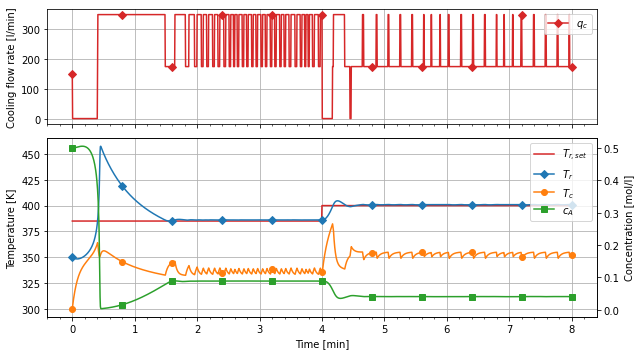

In [9]:
t, cA, Tr, Tc, qc, Tsp = np.asarray(result).T
plot_result(t, cA, Tr, Tc, qc, Tsp)